In [ ]:
# =============================================================
# 1. Imports and Setup
# =============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import cv2
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

✅ Using device: cuda


In [ ]:
# =============================================================
# 1. Imports
# =============================================================
import os
import random
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A

# =============================================================
# 2. Paths (DATASET NOT SPLIT ✅)
# =============================================================
base_dir = "/kaggle/input/bus-bra/BUSBRA/BUSBRA"

IMG_DIR = os.path.join(base_dir, "Images")
MASK_DIR = os.path.join(base_dir, "Masks")

# =============================================================
# 3. Hyperparameters
# =============================================================
IMG_SIZE = 256
BATCH_SIZE = 2
SEED = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# =============================================================
# 4. Dataset Class
# =============================================================
class LiverDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))

        assert len(self.images) == len(self.masks), "Images and masks count mismatch"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = np.array(
            Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        ) / 255.0

        mask = np.array(
            Image.open(mask_path).convert("L").resize((IMG_SIZE, IMG_SIZE))
        ) / 255.0

        mask = (mask > 0.5).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image = torch.tensor(image).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

# =============================================================
# 5. Augmentations
# =============================================================
train_transform = A.Compose([
    A.Resize(256, 256),
    A.RandomCrop(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.01,
        scale_limit=(-0.04, 0.04),
        rotate_limit=(-15, 15),
        p=0.5
    ),
])

val_transform = A.Compose([
    A.Resize(256, 256),
])

test_transform = A.Compose([
    A.Resize(256, 256),
])

# =============================================================
# 6. Full Dataset Load
# =============================================================
full_dataset = LiverDataset(IMG_DIR, MASK_DIR, transform=None)

# =============================================================
# 7. Split Dataset (70/10/20)
# =============================================================
total_size = len(full_dataset)

train_size = int(0.70 * total_size)
val_size   = int(0.10 * total_size)
test_size  = total_size - train_size - val_size  # ensures total matches

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

#Assign correct transforms AFTER split
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = test_transform

# =============================================================
# 8. DataLoaders
# =============================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =============================================================
# 9. Sanity Check
# =============================================================
print("Dataset loaded and split successfully!")
print(f"Total samples: {total_size}")
print(f"Train samples: {len(train_dataset)} ({len(train_dataset)/total_size:.2%})")
print(f"Val samples  : {len(val_dataset)} ({len(val_dataset)/total_size:.2%})")
print(f"Test samples : {len(test_dataset)} ({len(test_dataset)/total_size:.2%})")

✅ Dataset loaded and split successfully!
Total samples: 1875
Train samples: 1312 (69.97%)
Val samples  : 187 (9.97%)
Test samples : 376 (20.05%)


In [3]:
# =============================================================
# U-Net with SE Attention + Embedded Non-Cooperative Pixel Game
# (Single File, Structure Preserved)
# =============================================================
from torchinfo import summary
import torch
import torch.nn as nn

# =============================================================
# Double Convolution Block (UNCHANGED)
# =============================================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

# =============================================================
# Squeeze-and-Excitation (SE) Block
# =============================================================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

# =============================================================
# Boundary Strategy (Player 2)
# =============================================================
class BoundaryStrategy(nn.Module):
    """
    Extracts neighborhood (boundary pixel) response
    """
    def __init__(self, kernel_size=3):
        super().__init__()
        self.pool = nn.AvgPool2d(
            kernel_size=kernel_size,
            stride=1,
            padding=kernel_size // 2
        )

    def forward(self, x):
        return self.pool(x)

# =============================================================
# Strategy Interaction (Non-Cooperative Resolution)
# =============================================================
class StrategyInteraction(nn.Module):
    """
    Resolves disagreement between central and boundary pixels
    """
    def __init__(self, channels):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Conv2d(channels * 2, channels, 1),
            nn.BatchNorm2d(channels),
            nn.Sigmoid()
        )

    def forward(self, p1, p2):
        # Soft Nash-style equilibrium
        g = self.gate(torch.cat([p1, p2], dim=1))
        return g * p1 + (1 - g) * p2

# =============================================================
# U-Net with Embedded Non-Cooperative Game
# =============================================================
class UNet_GameSE(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()

        # ---------------- Encoder ----------------
        self.enc1 = DoubleConv(n_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.se1 = SEBlock(64)
        self.se2 = SEBlock(128)
        self.se3 = SEBlock(256)
        self.se4 = SEBlock(512)

        self.pool = nn.MaxPool2d(2)

        # ---------------- Bottleneck ----------------
        self.bottleneck = DoubleConv(512, 1024)
        self.se_bottleneck = SEBlock(1024)

        # ---------------- Decoder ----------------
        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec1 = DoubleConv(1024, 512)
        self.se_d1 = SEBlock(512)

        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec2 = DoubleConv(512, 256)
        self.se_d2 = SEBlock(256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.se_d3 = SEBlock(128)

        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec4 = DoubleConv(128, 64)
        self.se_d4 = SEBlock(64)

        # ---------------- Game Modules ----------------
        self.boundary = BoundaryStrategy(kernel_size=3)
        self.game = StrategyInteraction(64)

        # ---------------- Output ----------------
        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        # -------- Encoder --------
        c1 = self.se1(self.enc1(x))
        c2 = self.se2(self.enc2(self.pool(c1)))
        c3 = self.se3(self.enc3(self.pool(c2)))
        c4 = self.se4(self.enc4(self.pool(c3)))

        # -------- Bottleneck --------
        b = self.se_bottleneck(self.bottleneck(self.pool(c4)))

        # -------- Decoder --------
        d1 = self.se_d1(self.dec1(torch.cat([self.up1(b), c4], dim=1)))
        d2 = self.se_d2(self.dec2(torch.cat([self.up2(d1), c3], dim=1)))
        d3 = self.se_d3(self.dec3(torch.cat([self.up3(d2), c2], dim=1)))
        d4 = self.se_d4(self.dec4(torch.cat([self.up4(d3), c1], dim=1)))

        # -------- Non-Cooperative Pixel Game --------
        p1 = d4                    # Player 1: central pixel belief
        p2 = self.boundary(d4)     # Player 2: boundary response
        equilibrium = self.game(p1, p2)

        return torch.sigmoid(self.final(equilibrium))

# =============================================================
# Print Model Summary
# =============================================================
if __name__ == "__main__":
    model = UNet_GameSE(n_channels=3, n_classes=1)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    print("\n================= MODEL SUMMARY =================\n")
    print(summary(model, input_size=(2, 3, 256, 256)))


================= MODEL SUMMARY =================

Layer (type:depth-idx)                   Output Shape              Param #
UNet_GameSE                              [2, 1, 256, 256]          --
├─DoubleConv: 1-1                        [2, 64, 256, 256]         --
│    └─Sequential: 2-1                   [2, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                  [2, 64, 256, 256]         1,792
│    │    └─BatchNorm2d: 3-2             [2, 64, 256, 256]         128
│    │    └─ReLU: 3-3                    [2, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                  [2, 64, 256, 256]         36,928
│    │    └─BatchNorm2d: 3-5             [2, 64, 256, 256]         128
│    │    └─ReLU: 3-6                    [2, 64, 256, 256]         --
├─SEBlock: 1-2                           [2, 64, 256, 256]         --
│    └─AdaptiveAvgPool2d: 2-2            [2, 64, 1, 1]             --
│    └─Sequential: 2-3                   [2, 64]                   --
│    │    └─Linear: 3-7 

Epoch 1/100 [Val]: 100%|██████████| 94/94 [00:02<00:00, 37.28it/s]



Epoch 1/100
Train Loss: 0.5027 | Val Loss: 0.3372
Train Dice: 0.3172 | Val Dice: 0.4986
Train IoU : 0.4216 | Val IoU : 0.5764
✅ Best model saved (Epoch 1, Val Loss 0.3372)


Epoch 2/100 [Val]: 100%|██████████| 94/94 [00:02<00:00, 38.31it/s]



Epoch 2/100
Train Loss: 0.2793 | Val Loss: 0.2187
Train Dice: 0.5874 | Val Dice: 0.6710
Train IoU : 0.5969 | Val IoU : 0.6564
✅ Best model saved (Epoch 2, Val Loss 0.2187)


Epoch 3/100 [Val]: 100%|██████████| 94/94 [00:02<00:00, 37.70it/s]


...


Epoch 98/100
Train Loss: 0.0123 | Val Loss: 0.1242
Train Dice: 0.9824 | Val Dice: 0.8854
Train IoU : 0.9686 | Val IoU : 0.8083


Epoch 99/100 [Val]: 100%|██████████| 94/94 [00:02<00:00, 37.49it/s]



Epoch 99/100
Train Loss: 0.0124 | Val Loss: 0.1203
Train Dice: 0.9823 | Val Dice: 0.8887
Train IoU : 0.9684 | Val IoU : 0.8132


Epoch 100/100 [Val]: 100%|██████████| 94/94 [00:02<00:00, 37.43it/s]



Epoch 100/100
Train Loss: 0.0121 | Val Loss: 0.1235
Train Dice: 0.9827 | Val Dice: 0.8893
Train IoU : 0.9691 | Val IoU : 0.8135

🎉 Training Completed!
🏆 Best Epoch: 30
✔ Best Val Loss: 0.0889


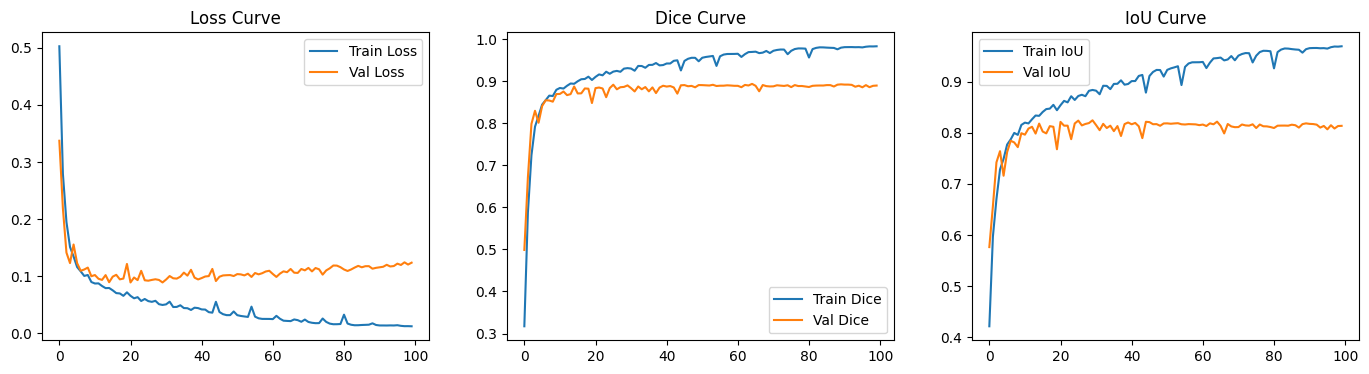

In [ ]:
# =============================================================
# LOSS + METRICS
# =============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt


# BCE + Dice Loss
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCELoss()

    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)

        preds_f = preds.view(-1)
        targets_f = targets.view(-1)
        inter = (preds_f * targets_f).sum()
        dice_loss = 1 - (2 * inter + self.smooth) / \
                        (preds_f.sum() + targets_f.sum() + self.smooth)

        return 0.5 * bce_loss + 0.5 * dice_loss


# Dice Metric
def dice_coef(y_true, y_pred, smooth=1e-5):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    inter = (y_true_f * y_pred_f).sum()
    return (2. * inter + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)


# IoU Metric
def iou_score(preds, masks, threshold=0.5, eps=1e-6):
    preds_bin = (preds > threshold).float()
    masks_bin = (masks > threshold).float()

    inter = (preds_bin * masks_bin).sum().item()
    union = preds_bin.sum().item() + masks_bin.sum().item() - inter

    return inter / (union + eps)


# =============================================================
# TRAINING LOOP
# =============================================================
def train_model(model, train_loader, val_loader, epochs=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    criterion = BCEDiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Tracking curves
    train_losses, val_losses = [], []
    train_dice_scores, val_dice_scores = [], []
    train_iou_scores, val_iou_scores = [], []

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_weights = None

    for epoch in range(epochs):

        # ------------------ TRAIN ------------------
        model.train()
        train_loss = train_dice = train_iou = 0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulate
            train_loss += loss.item()
            train_dice += dice_coef(masks, preds).item()
            train_iou += iou_score(preds, masks)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = val_dice = val_iou = 0

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images, masks = images.to(device), masks.to(device)

                preds = model(images)
                val_loss += criterion(preds, masks).item()
                val_dice += dice_coef(masks, preds).item()
                val_iou += iou_score(preds, masks)

        # ------------------ AVERAGES ------------------
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss / len(val_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_val_dice   = val_dice / len(val_loader)
        avg_train_iou  = train_iou / len(train_loader)
        avg_val_iou    = val_iou / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_dice_scores.append(avg_train_dice)
        val_dice_scores.append(avg_val_dice)
        train_iou_scores.append(avg_train_iou)
        val_iou_scores.append(avg_val_iou)

        # ------------------ PRINT ------------------
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f}")
        print(f"Train IoU : {avg_train_iou:.4f} | Val IoU : {avg_val_iou:.4f}")

        # ------------------ SAVE BEST ------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_unet_monu.pth")
            print(f"Best model saved (Epoch {epoch+1}, Val Loss {best_val_loss:.4f})")

    # ------------------ LOAD BEST MODEL ------------------
    model.load_state_dict(best_model_weights)

    print("\n Training Completed!")
    print(f" Best Epoch: {best_epoch}")
    print(f" Best Val Loss: {best_val_loss:.4f}")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_dice": train_dice_scores,
        "val_dice": val_dice_scores,
        "train_iou": train_iou_scores,
        "val_iou": val_iou_scores,
    }


# =============================================================
# PLOTTING FUNCTION
# =============================================================
def plot_training(history):
    plt.figure(figsize=(17, 4))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(history["train_losses"], label="Train Loss")
    plt.plot(history["val_losses"], label="Val Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Dice
    plt.subplot(1, 3, 2)
    plt.plot(history["train_dice"], label="Train Dice")
    plt.plot(history["val_dice"], label="Val Dice")
    plt.title("Dice Curve")
    plt.legend()

    # IoU
    plt.subplot(1, 3, 3)
    plt.plot(history["train_iou"], label="Train IoU")
    plt.plot(history["val_iou"], label="Val IoU")
    plt.title("IoU Curve")
    plt.legend()

    plt.show()

model = UNet_GameSE().to(device)
history = train_model(model, train_loader, val_loader, epochs=100)
plot_training(history)

📥 Loading best model...
🧪 Evaluating on test set...


Evaluating Test Set: 100%|██████████| 376/376 [00:05<00:00, 67.05it/s]



🎯 TEST SET EVALUATION
✅ Dice Coefficient: 0.8913
✅ IoU (Jaccard):    0.8162

📊 Generating visualizations...


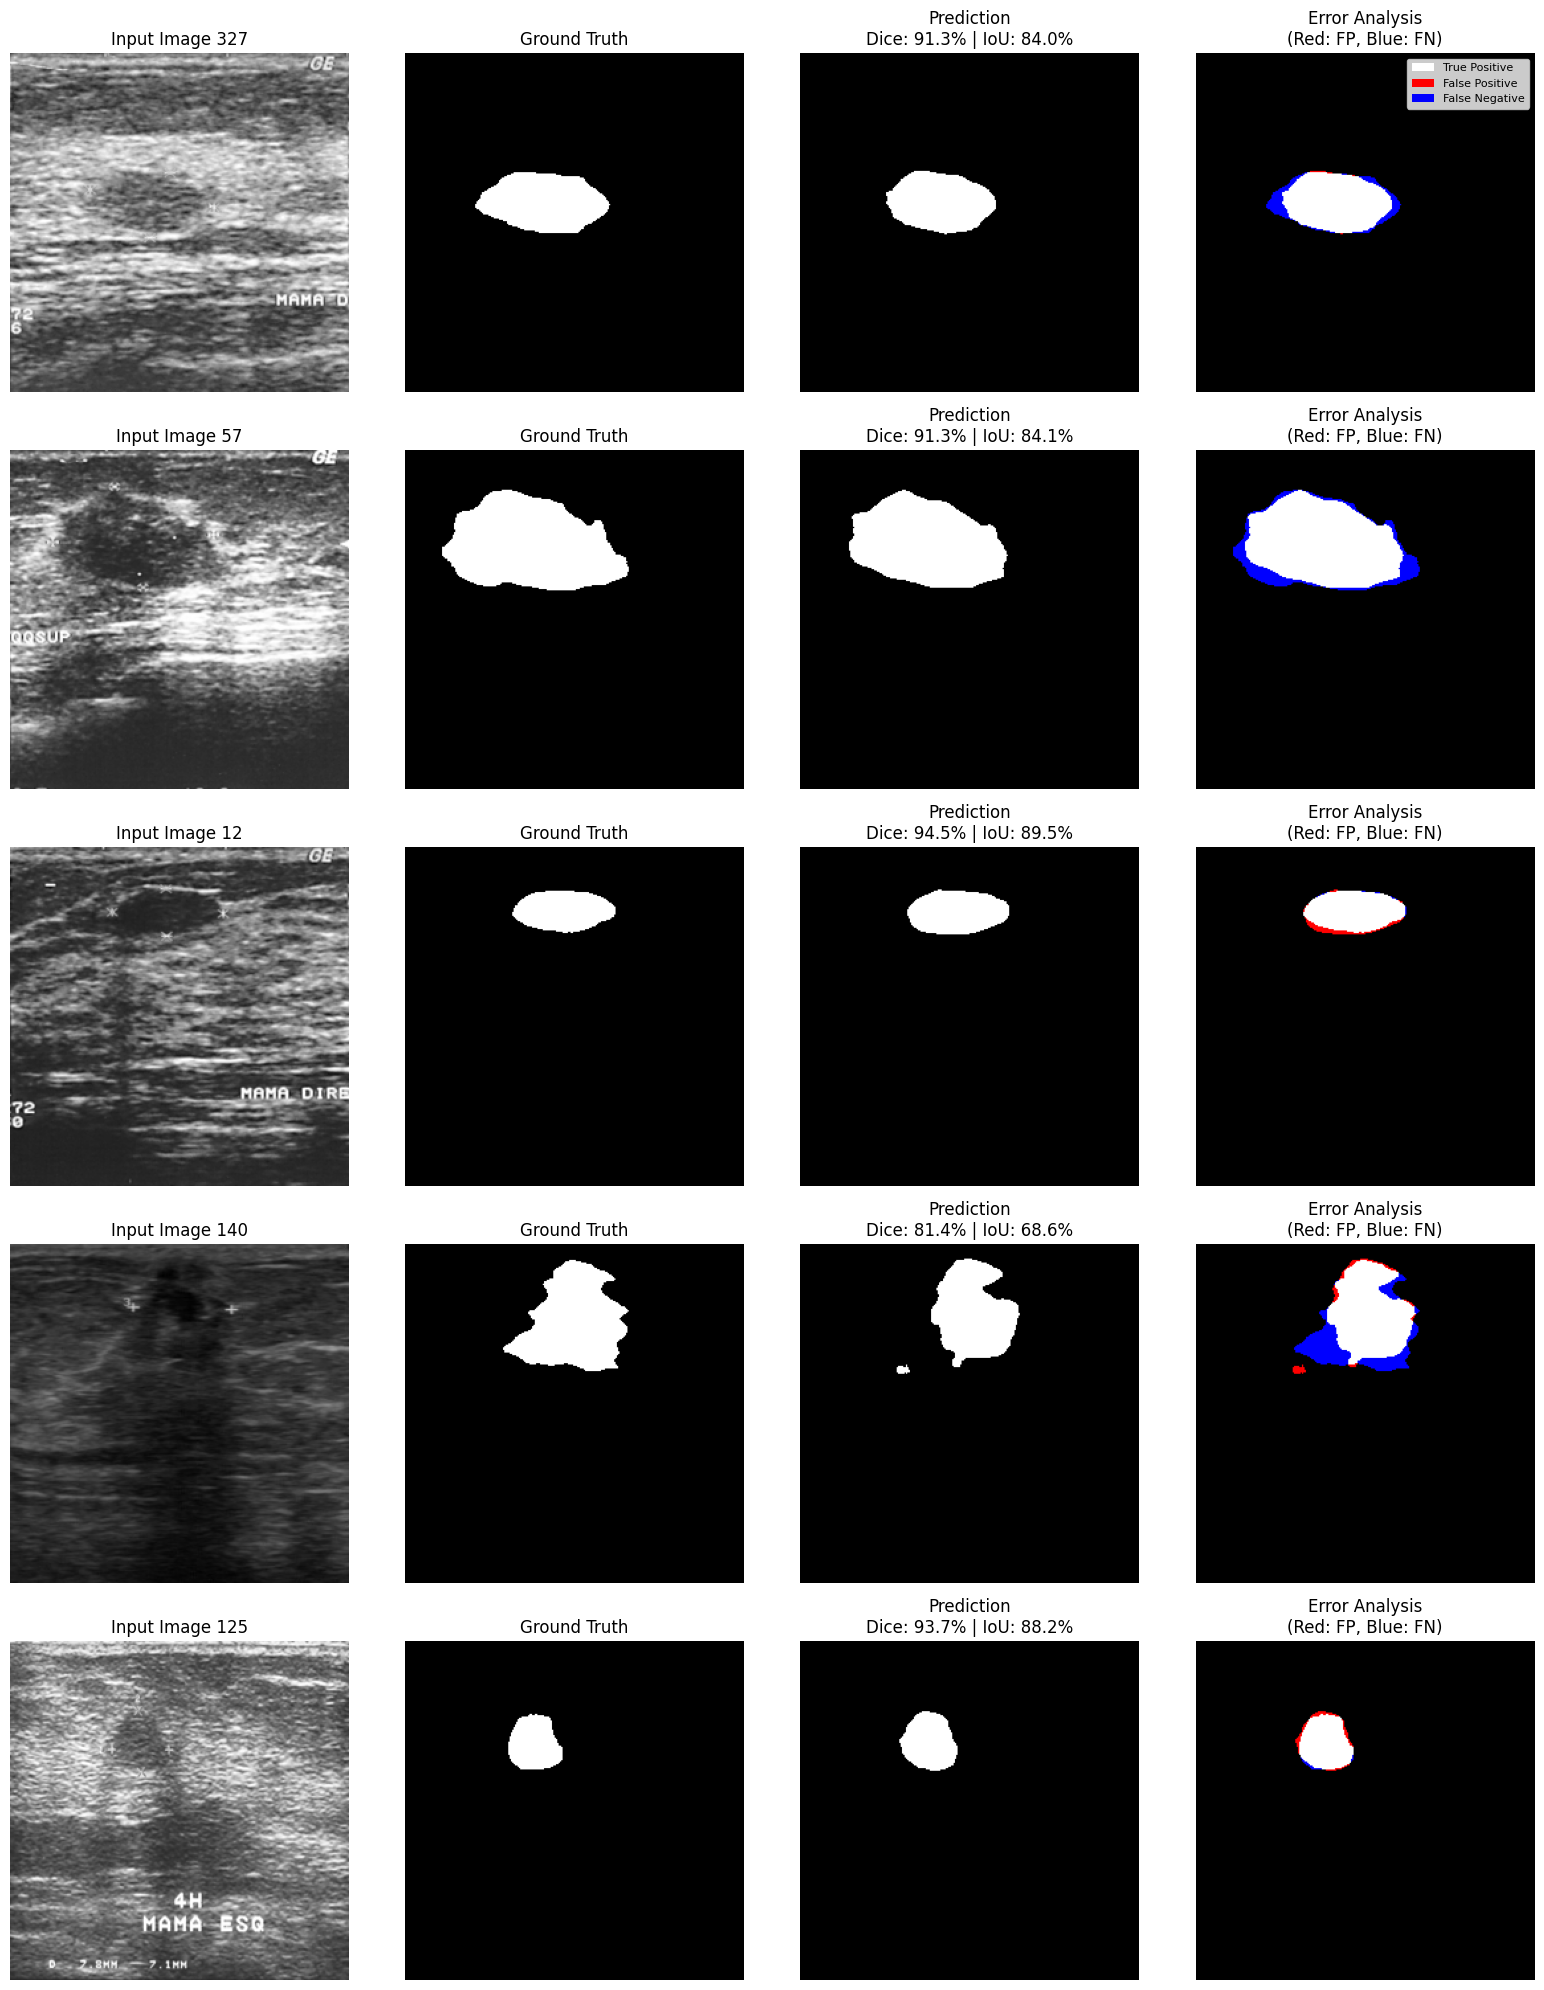


🎉 Evaluation completed successfully!


In [ ]:
# =============================================================
# Simplified Test Evaluation (Only Dice and IoU)
# =============================================================

import numpy as np

def iou_coef(y_true, y_pred, smooth=1e-5):
    """
    Intersection over Union (IoU) metric for binary masks.
    """
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    intersection = (y_true_f * y_pred_f).sum()
    union = y_true_f.sum() + y_pred_f.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# Load the best model
print(" Loading best model...")
model.load_state_dict(torch.load("best_unet_monu.pth", map_location=device))
model.eval()

# Initialize accumulators for metrics
test_dice, test_iou = 0, 0

print(" Evaluating on test set...")

# Loop through test data
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Evaluating Test Set"):
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        preds_bin = (preds > 0.5).float()   # threshold at 0.5

        # Accumulate metrics
        test_dice += dice_coef(masks, preds_bin).item()
        test_iou += iou_coef(masks, preds_bin).item()

# Average metrics
num_batches = len(test_loader)
avg_test_dice = test_dice / num_batches
avg_test_iou = test_iou / num_batches

# Print simplified results
print("\n" + "="*40)
print(" TEST SET EVALUATION")
print("="*40)
print(f" Dice Coefficient: {avg_test_dice:.4f}")
print(f" IoU (Jaccard):    {avg_test_iou:.4f}")
print("="*40)

# =============================================================
# Simplified Visualization (Only Dice and IoU)
# =============================================================

def dice_coef_single(y_true, y_pred, smooth=1e-5):
    """Compute Dice coefficient for one pair of masks"""
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def iou_coef_single(y_true, y_pred, smooth=1e-5):
    """Compute IoU for one pair of masks"""
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + smooth)

def visualize_predictions_simple(model, dataset, num_samples=5, threshold=0.5):
    """
    Simplified visualization with dice, iou and error analysis
    """
    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 4))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]

        with torch.no_grad():
            pred_prob = model(image.unsqueeze(0).to(device)).cpu().squeeze().numpy()

        pred_mask = (pred_prob > threshold).astype(np.uint8)
        true_mask = mask.squeeze().numpy().astype(np.uint8)
        
        # Compute metrics
        dice_score = dice_coef_single(true_mask, pred_mask) * 100
        iou_score = iou_coef_single(true_mask, pred_mask) * 100
        
        # Create error map (FP: red, FN: blue, TP: white, TN: black)
        error_map = np.zeros((*true_mask.shape, 3), dtype=np.uint8)
        true_positive = (true_mask == 1) & (pred_mask == 1)
        false_positive = (true_mask == 0) & (pred_mask == 1)
        false_negative = (true_mask == 1) & (pred_mask == 0)
        
        error_map[true_positive] = [255, 255, 255]  # White for TP
        error_map[false_positive] = [255, 0, 0]     # Red for FP
        error_map[false_negative] = [0, 0, 255]     # Blue for FN

        # Plot 1: Original Image
        axes[i, 0].imshow(image.permute(1, 2, 0) if image.shape[0] == 3 else image.squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Input Image {idx}")
        axes[i, 0].axis("off")
        
        # Plot 2: Ground Truth
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")
        
        # Plot 3: Predicted Mask
        axes[i, 2].imshow(pred_mask, cmap="gray")
        axes[i, 2].set_title(f"Prediction\nDice: {dice_score:.1f}% | IoU: {iou_score:.1f}%")
        axes[i, 2].axis("off")
        
        # Plot 4: Error Analysis
        axes[i, 3].imshow(error_map)
        axes[i, 3].set_title("Error Analysis\n(Red: FP, Blue: FN)")
        axes[i, 3].axis("off")
        
        # Add legend for error map (only for first row)
        if i == 0:
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='white', label='True Positive'),
                Patch(facecolor='red', label='False Positive'),
                Patch(facecolor='blue', label='False Negative')
            ]
            axes[i, 3].legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()
    
    return indices

# Run simplified visualization
print("\n Generating visualizations...")
sampled_indices = visualize_predictions_simple(model, test_dataset, num_samples=5)

print("\n Evaluation completed successfully!")